# Imports and config

In [18]:
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import tv_tensors
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import v2
from tqdm.auto import tqdm

# Configure plot styling for better readability
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_theme(style="whitegrid")

# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Data loading

By default, the Oxford-IIIT Pet dataset is split into `trainval` and `test`.

The final configuration is:
* **Train:** 80% of `trainval` (used to update model weights).
* **Validation:** 20% of `trainval` (used to evaluate performance after each epoch and select architectures).
* **Test:** 100% of the original `test` set (untouched until the final evaluation of the best model).

In [4]:
data_dir = Path.cwd() / "data"

full_train_dataset = OxfordIIITPet(root=data_dir, split='trainval', target_types=['category', 'segmentation'], download=True)
test_dataset = OxfordIIITPet(root=data_dir, split='test', target_types=['category', 'segmentation'], download=True)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f"Total number of classes: {num_classes}")

Training samples: 2944
Validation samples: 736
Test samples: 3669
Total number of classes: 37


# Data pipeline

To prevent overfitting, I implement a data augmentation pipeline.

In [5]:
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transforms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMG_MEAN, std=IMG_STD)
])

val_transforms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMG_MEAN, std=IMG_STD)
])

class PetDatasetWrapper(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, (label, mask) = self.base_dataset[idx]
        
        img_tensor = tv_tensors.Image(img)
        mask_tensor = tv_tensors.Mask(mask)

        if self.transform:
            img_tensor, mask_tensor = self.transform(img_tensor, mask_tensor)

        mask_tensor = torch.as_tensor(mask_tensor, dtype=torch.long).squeeze() - 1

        return img_tensor, label, mask_tensor

aug_train_dataset = PetDatasetWrapper(train_dataset, transform=train_transforms)
aug_val_dataset = PetDatasetWrapper(val_dataset, transform=val_transforms)
aug_test_dataset = PetDatasetWrapper(test_dataset, transform=val_transforms)

--- Displaying Standard Augmented Batch ---


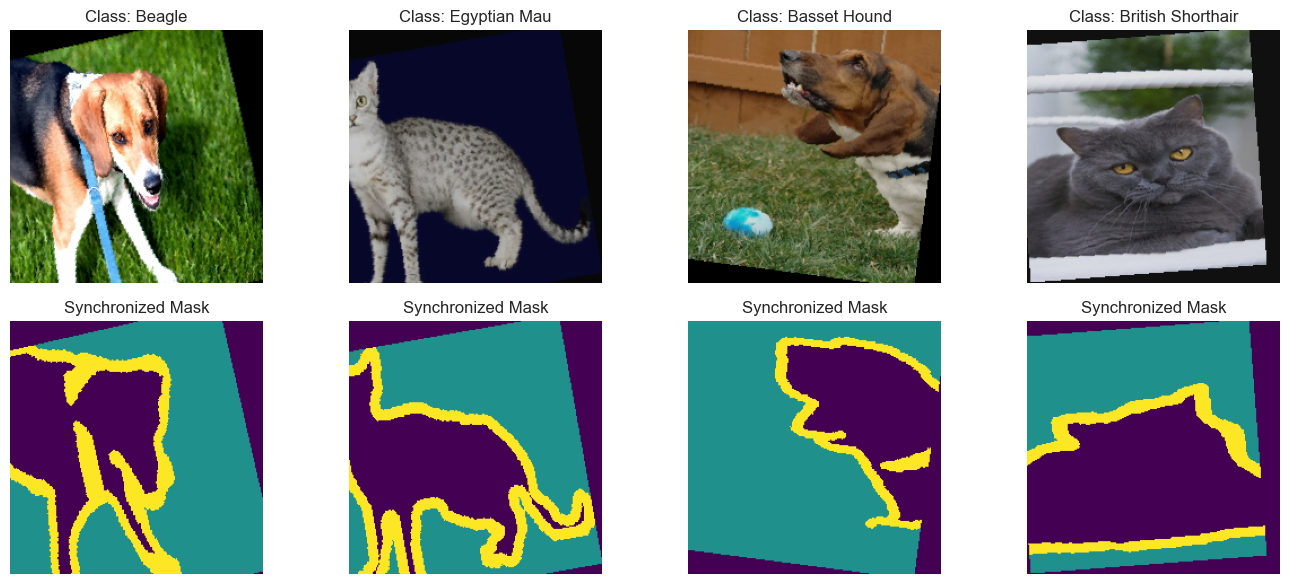

--- Displaying Batch with Segmentation CutMix Applied ---


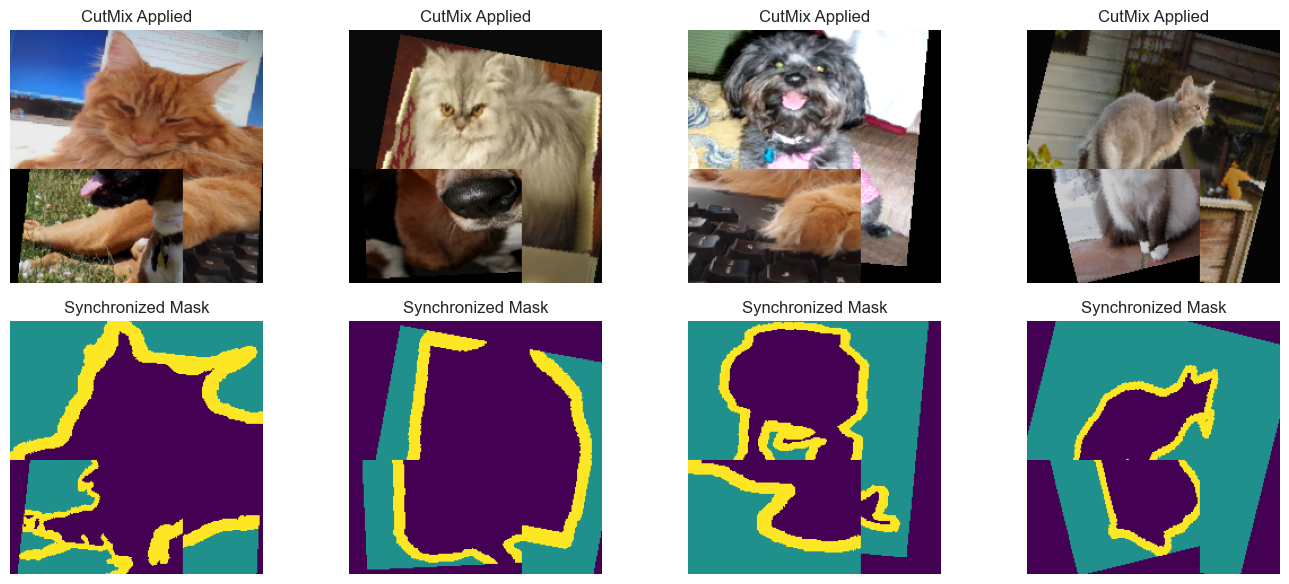

In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(aug_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(aug_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

num_classes = len(class_names)
cutmix = v2.CutMix(alpha=1.0, num_classes=num_classes)

def denormalize(tensor):
    mean = torch.tensor(IMG_MEAN).view(3, 1, 1)
    std = torch.tensor(IMG_STD).view(3, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

def apply_segmentation_cutmix(images, masks, alpha=1.0):
    """
    Custom CutMix that spatially cuts and pastes both the image and the 
    corresponding dense segmentation mask perfectly in sync.
    """
    batch_size, _, H, W = images.shape
    
    # Create a random permutation of indices to shuffle the batch
    indices = torch.randperm(batch_size)
    
    # Sample lambda from a Beta distribution
    lam = np.random.beta(alpha, alpha)
    
    # Calculate bounding box dimensions based on lambda
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    
    # Pick a random center for the cut
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    
    # Define the bounding box coordinates
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    
    # Clone to prevent modifying the original batch in-place
    mixed_images = images.clone()
    mixed_masks = masks.clone()
    
    # Paste the patches into both the images and the masks
    mixed_images[:, :, bby1:bby2, bbx1:bbx2] = images[indices, :, bby1:bby2, bbx1:bbx2]
    mixed_masks[:, bby1:bby2, bbx1:bbx2] = masks[indices, bby1:bby2, bbx1:bbx2]
    
    return mixed_images, mixed_masks

def display_augmented_batch(dataloader, apply_cutmix=False):
    images, labels, masks = next(iter(dataloader))
    
    # Apply our custom segmentation CutMix
    if apply_cutmix:
        images, masks = apply_segmentation_cutmix(images, masks)

    plt.figure(figsize=(14, 6))
    for i in range(4): # Display 4 examples from the batch
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        mask = masks[i].numpy()
        
        # Display Image
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        
        if apply_cutmix:
            plt.title("CutMix Applied")
        else:
            plt.title(f"Class: {class_names[labels[i]]}")
        plt.axis('off')
        
        # Display Synchronized Mask
        plt.subplot(2, 4, i + 5)
        plt.imshow(mask, vmin=0, vmax=2, cmap='viridis')
        plt.title("Synchronized Mask")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

print("--- Displaying Standard Augmented Batch ---")
display_augmented_batch(train_loader, apply_cutmix=False)

print("--- Displaying Batch with Segmentation CutMix Applied ---")
display_augmented_batch(train_loader, apply_cutmix=True)

# Custom CNN

In [5]:
class CustomPetCNN(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 112x112 -> 56x56
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 56x56 -> 28x28
        )
        
        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 28x28 -> 14x14
        )
        
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

baseline_model = CustomPetCNN(num_classes=num_classes).to(device)

# Check parameter count
total_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 400,421


In [6]:
EPOCHS = 25
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=learning_rate)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting baseline training...")

for epoch in range(EPOCHS):
    baseline_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    baseline_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = baseline_model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

Starting baseline training...


Epoch 1/25 [Train]: 100%|██████████| 92/92 [00:31<00:00,  2.93it/s]


Epoch 01 | Train Loss: 3.6743 | Train Acc: 0.0340 | Val Loss: 3.5665 | Val Acc: 0.0394


Epoch 2/25 [Train]: 100%|██████████| 92/92 [00:29<00:00,  3.17it/s]


Epoch 02 | Train Loss: 3.5508 | Train Acc: 0.0486 | Val Loss: 3.5190 | Val Acc: 0.0611


...

Epoch 23 | Train Loss: 2.7630 | Train Acc: 0.2303 | Val Loss: 2.9399 | Val Acc: 0.1984


Epoch 24/25 [Train]: 100%|██████████| 92/92 [00:28<00:00,  3.21it/s]


Epoch 24 | Train Loss: 2.7460 | Train Acc: 0.2463 | Val Loss: 2.8754 | Val Acc: 0.2283


Epoch 25/25 [Train]: 100%|██████████| 92/92 [00:30<00:00,  3.07it/s]


Epoch 25 | Train Loss: 2.7350 | Train Acc: 0.2490 | Val Loss: 3.9575 | Val Acc: 0.1264


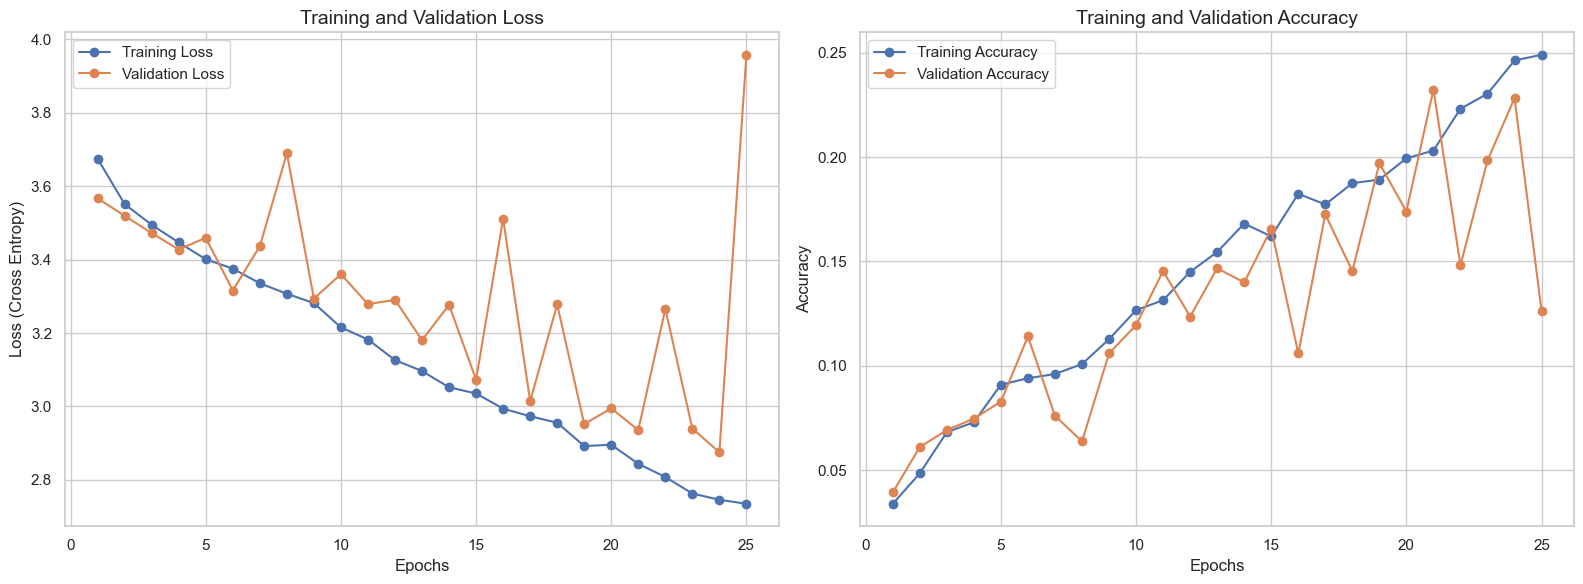

Overfitting likely began after Epoch 24, where validation loss was lowest.


In [7]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross Entropy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

best_val_epoch = np.argmin(history['val_loss']) + 1
print(f"Overfitting likely began after Epoch {best_val_epoch}, where validation loss was lowest.")

# Transfer learning

In this phase, we treat the pre-trained convolutional base as an arbitrary feature extractor. We will:
1. **Freeze** all weights in the base network so they do not update during backpropagation.
2. **Replace** the final classification head with a new, randomly initialized Linear layer scaled to our 37 pet classes.
3. **Train** only this new head.

We will compare **ResNet50**, **EfficientNetB0**, and **ConvNeXt-Tiny**.

In [2]:
def setup_feature_extractor(model_name, num_classes=37):
    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        
        # Freeze base
        for param in model.parameters():
            param.requires_grad = False
            
        # Replace head
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        
    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        
        # Freeze base
        for param in model.parameters():
            param.requires_grad = False
            
        # Replace head
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        
    elif model_name == 'convnext_tiny':
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)
        
        # Freeze base
        for param in model.parameters():
            param.requires_grad = False
            
        # Replace head
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
        
    else:
        raise ValueError("Unsupported model.")
        
    return model.to(device)

models_dict = {
    'ResNet50': setup_feature_extractor('resnet50'),
    'EfficientNetB0': setup_feature_extractor('efficientnet_b0'),
    'ConvNeXt-Tiny': setup_feature_extractor('convnext_tiny')
}

print(f"{'Model':<18} | {'Total Params':<15} | {'Trainable Params':<18}")
print("-" * 55)
for name, model in models_dict.items():
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:<18} | {total_params:<15,} | {trainable_params:<18,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\kacpe/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:50<00:00, 2.02MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\kacpe/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:08<00:00, 2.42MB/s]
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\kacpe/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [01:21<00:00, 1.40MB/s] 


Model              | Total Params    | Trainable Params  
-------------------------------------------------------
ResNet50           | 23,583,845      | 75,813            
EfficientNetB0     | 4,054,945       | 47,397            
ConvNeXt-Tiny      | 27,848,581      | 28,453            


In [7]:
def train_model(model, model_name, epochs=5):
    print(f"\n--- Training {model_name} ---")
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_acc': [], 'val_acc': [], 'time_per_epoch': []}
    
    for epoch in range(epochs):
        start_time = time.perf_counter()
        
        model.train()
        correct, total = 0, 0
        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_acc = correct / total
        
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        val_acc = val_correct / val_total
        
        epoch_time = time.perf_counter() - start_time
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['time_per_epoch'].append(epoch_time)
        
        print(f"Epoch {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
    return history

histories = {}
for name, model in models_dict.items():
    histories[name] = train_model(model, name, epochs=5)


--- Training ResNet50 ---
Epoch 1/5 | Time: 36.05s | Train Acc: 0.6539 | Val Acc: 0.8641
Epoch 2/5 | Time: 33.50s | Train Acc: 0.9049 | Val Acc: 0.8913
Epoch 3/5 | Time: 32.97s | Train Acc: 0.9321 | Val Acc: 0.8872
Epoch 4/5 | Time: 32.81s | Train Acc: 0.9426 | Val Acc: 0.9049
Epoch 5/5 | Time: 32.61s | Train Acc: 0.9558 | Val Acc: 0.9117

--- Training EfficientNetB0 ---
Epoch 1/5 | Time: 31.69s | Train Acc: 0.5336 | Val Acc: 0.7595
Epoch 2/5 | Time: 32.00s | Train Acc: 0.7904 | Val Acc: 0.7894
Epoch 3/5 | Time: 32.70s | Train Acc: 0.8268 | Val Acc: 0.8030
Epoch 4/5 | Time: 32.05s | Train Acc: 0.8505 | Val Acc: 0.8166
Epoch 5/5 | Time: 31.95s | Train Acc: 0.8624 | Val Acc: 0.8288

--- Training ConvNeXt-Tiny ---
Epoch 1/5 | Time: 33.98s | Train Acc: 0.7656 | Val Acc: 0.9389
Epoch 2/5 | Time: 33.59s | Train Acc: 0.9378 | Val Acc: 0.9484
Epoch 3/5 | Time: 32.77s | Train Acc: 0.9501 | Val Acc: 0.9457
Epoch 4/5 | Time: 35.14s | Train Acc: 0.9579 | Val Acc: 0.9538
Epoch 5/5 | Time: 32.73s |

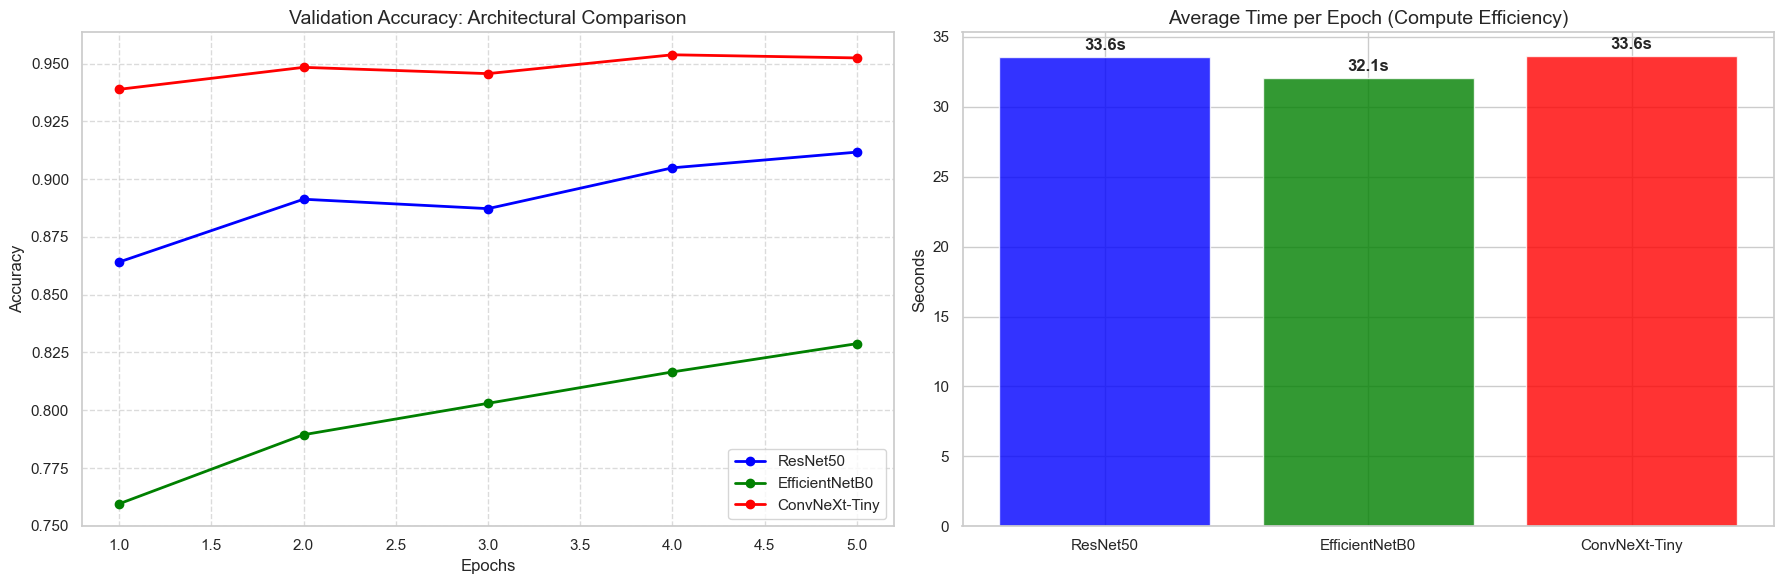

In [8]:
epochs_range = range(1, 6)
colors = {'ResNet50': 'blue', 'EfficientNetB0': 'green', 'ConvNeXt-Tiny': 'red'}

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
for name, hist in histories.items():
    plt.plot(epochs_range, hist['val_acc'], label=name, marker='o', color=colors[name], linewidth=2)
plt.title('Validation Accuracy: Architectural Comparison', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
avg_times = {name: np.mean(hist['time_per_epoch']) for name, hist in histories.items()}
plt.bar(avg_times.keys(), avg_times.values(), color=[colors[k] for k in avg_times], alpha=0.8)
plt.title('Average Time per Epoch (Compute Efficiency)', fontsize=14)
plt.ylabel('Seconds')
for i, v in enumerate(avg_times.values()):
    plt.text(i, v + 0.5, f"{v:.1f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Visualisations

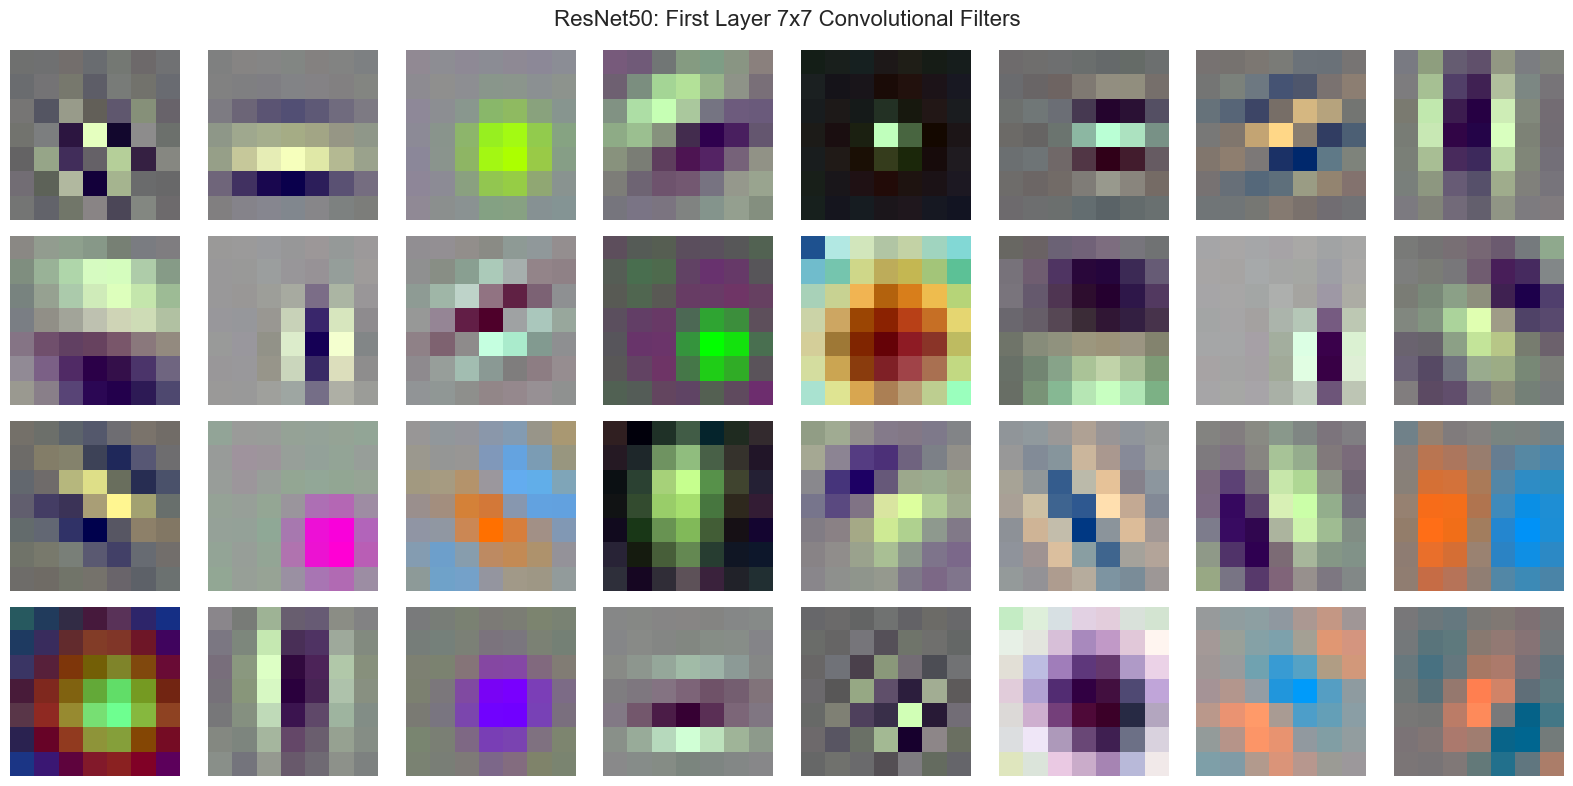

In [9]:
first_layer_weights = models_dict['ResNet50'].conv1.weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('ResNet50: First Layer 7x7 Convolutional Filters', fontsize=16)

for i, ax in enumerate(axes.flat):
    kernel = first_layer_weights[i].numpy()
    
    k_min, k_max = kernel.min(), kernel.max()
    kernel = (kernel - k_min) / (k_max - k_min)

    ax.imshow(np.transpose(kernel, (1, 2, 0)))
    ax.axis('off')

plt.tight_layout()
plt.show()

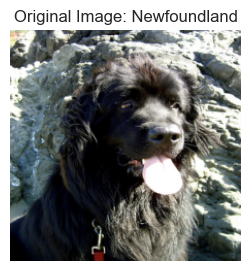

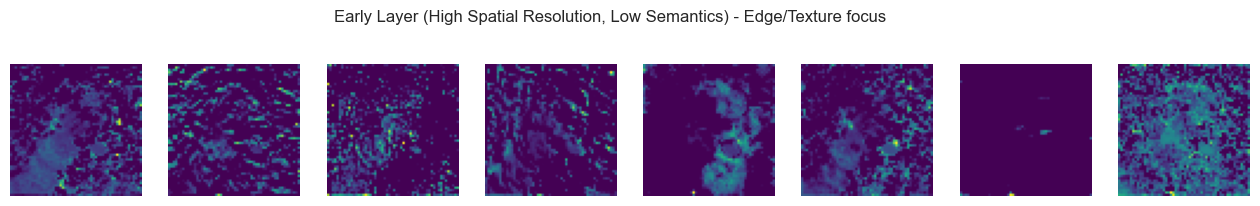

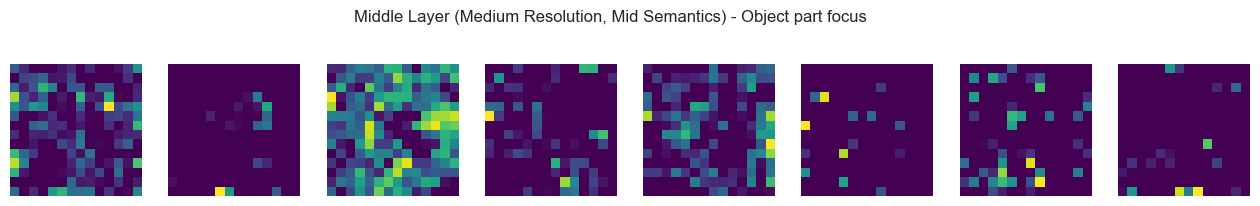

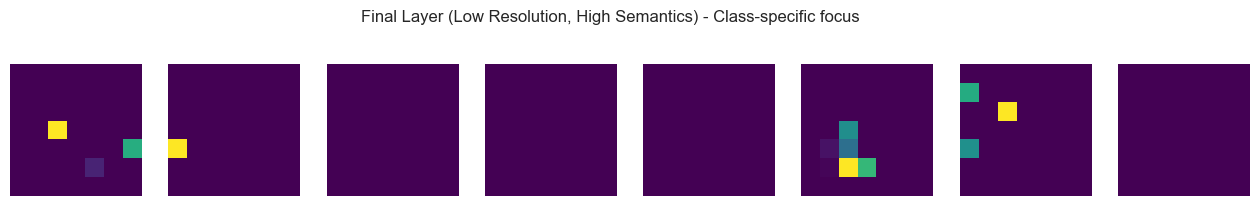

In [10]:
sample_img_tensor, label, _ = next(iter(val_loader))
sample_img = sample_img_tensor[0:1].to(device)
sample_label = label[0].item()

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

h1 = models_dict['ResNet50'].layer1[0].register_forward_hook(get_activation('Layer1_Block0'))
h2 = models_dict['ResNet50'].layer3[0].register_forward_hook(get_activation('Layer3_Block0'))
h3 = models_dict['ResNet50'].layer4[-1].register_forward_hook(get_activation('Layer4_Final'))

_ = models_dict['ResNet50'](sample_img)

h1.remove()
h2.remove()
h3.remove()

def plot_feature_maps(activation_tensor, title, num_channels=8):
    act = activation_tensor[0].numpy()
    fig, axes = plt.subplots(1, num_channels, figsize=(16, 2))
    fig.suptitle(title, fontsize=12, y=1.1)
    
    for i in range(num_channels):
        axes[i].imshow(act[i], cmap='viridis')
        axes[i].axis('off')
    plt.show()

plt.figure(figsize=(3, 3))
plt.imshow(denormalize(sample_img[0].cpu()).permute(1, 2, 0).numpy())
plt.title(f"Original Image: {class_names[sample_label]}")
plt.axis('off')
plt.show()

plot_feature_maps(activations['Layer1_Block0'], 'Early Layer (High Spatial Resolution, Low Semantics) - Edge/Texture focus')
plot_feature_maps(activations['Layer3_Block0'], 'Middle Layer (Medium Resolution, Mid Semantics) - Object part focus')
plot_feature_maps(activations['Layer4_Final'], 'Final Layer (Low Resolution, High Semantics) - Class-specific focus')

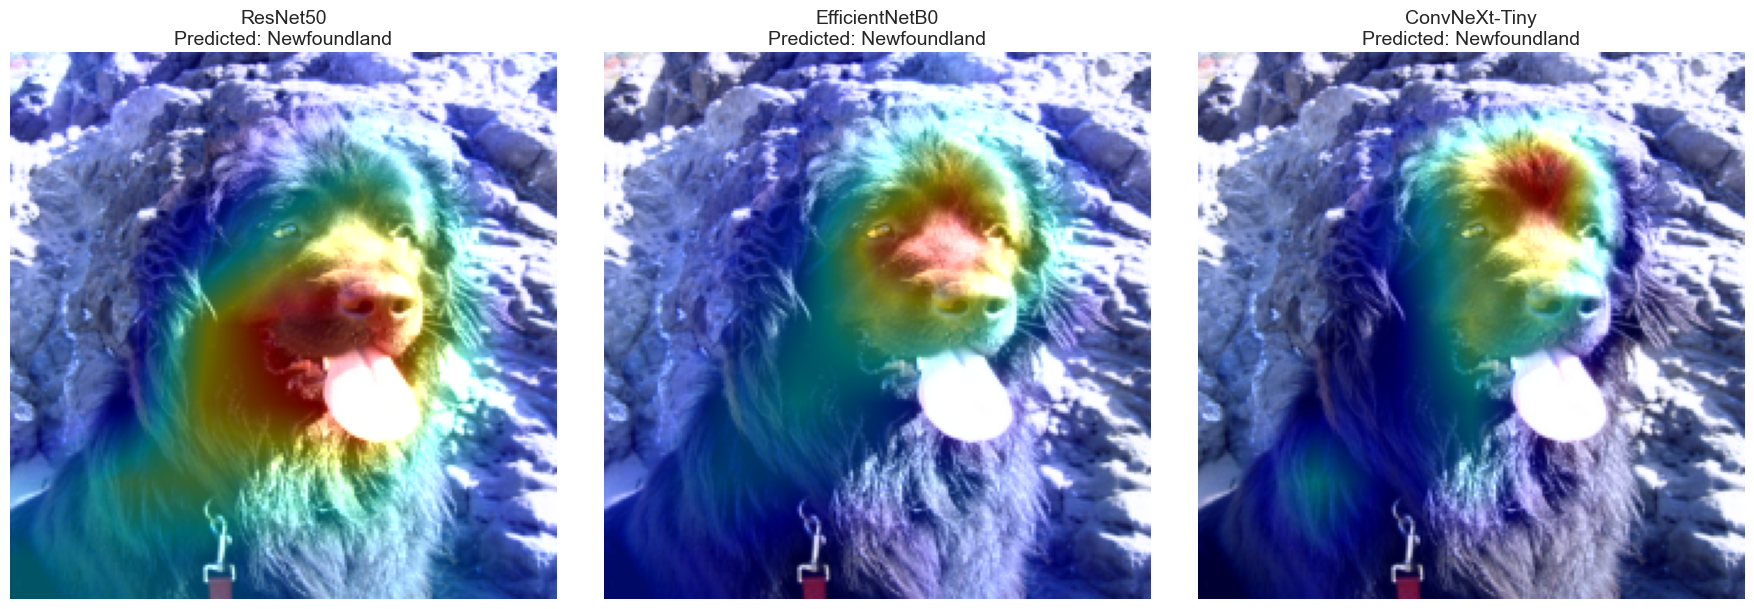

In [16]:
class MinimalGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        # THE FIX: Force Autograd to propagate gradients all the way back to the input
        x.requires_grad_()
        
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
            
        self.model.zero_grad()
        
        target = logits[0, class_idx]
        target.backward(retain_graph=True)
        
        # Pool the gradients across the spatial dimensions
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Extract the activations and detach them from the computational graph
        activations = self.activations[0].detach()
        pooled_gradients = pooled_gradients.detach()
        
        # Vectorized weighting of the channels (cleaner than the for-loop)
        activations = activations * pooled_gradients.view(-1, 1, 1)
        
        # Average across channels and apply ReLU
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, class_idx

def overlay_heatmap(img_tensor, heatmap):
    img = denormalize(img_tensor.cpu()).permute(1, 2, 0).detach().numpy()
    
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / 255
    heatmap_colored = heatmap_colored[..., ::-1]
    
    superimposed_img = heatmap_colored * 0.4 + img
    return np.clip(superimposed_img, 0, 1)
    

target_layers = {
    'ResNet50': models_dict['ResNet50'].layer4[-1].conv3,
    'EfficientNetB0': models_dict['EfficientNetB0'].features[-1],
    'ConvNeXt-Tiny': models_dict['ConvNeXt-Tiny'].features[-1]
}

plt.figure(figsize=(18, 6))

for idx, (name, target_layer) in enumerate(target_layers.items()):
    cam_generator = MinimalGradCAM(models_dict[name], target_layer)
    heatmap, pred_class = cam_generator(sample_img)
    
    overlay = overlay_heatmap(sample_img[0], heatmap)
    
    plt.subplot(1, 3, idx + 1)
    plt.imshow(overlay)
    plt.title(f"{name}\nPredicted: {class_names[pred_class]}", fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Evaluation


--- Detailed Classification Report ---
                            precision    recall  f1-score   support

                Abyssinian       0.94      0.89      0.91        18
          American Bulldog       0.83      0.86      0.84        22
 American Pit Bull Terrier       0.93      0.76      0.84        17
              Basset Hound       1.00      0.92      0.96        13
                    Beagle       1.00      1.00      1.00        15
                    Bengal       0.78      1.00      0.88        21
                    Birman       0.86      0.86      0.86        14
                    Bombay       0.89      1.00      0.94        16
                     Boxer       1.00      0.91      0.95        22
         British Shorthair       0.90      0.95      0.93        20
                 Chihuahua       1.00      1.00      1.00        23
              Egyptian Mau       1.00      0.96      0.98        23
    English Cocker Spaniel       1.00      0.95      0.97        19
       

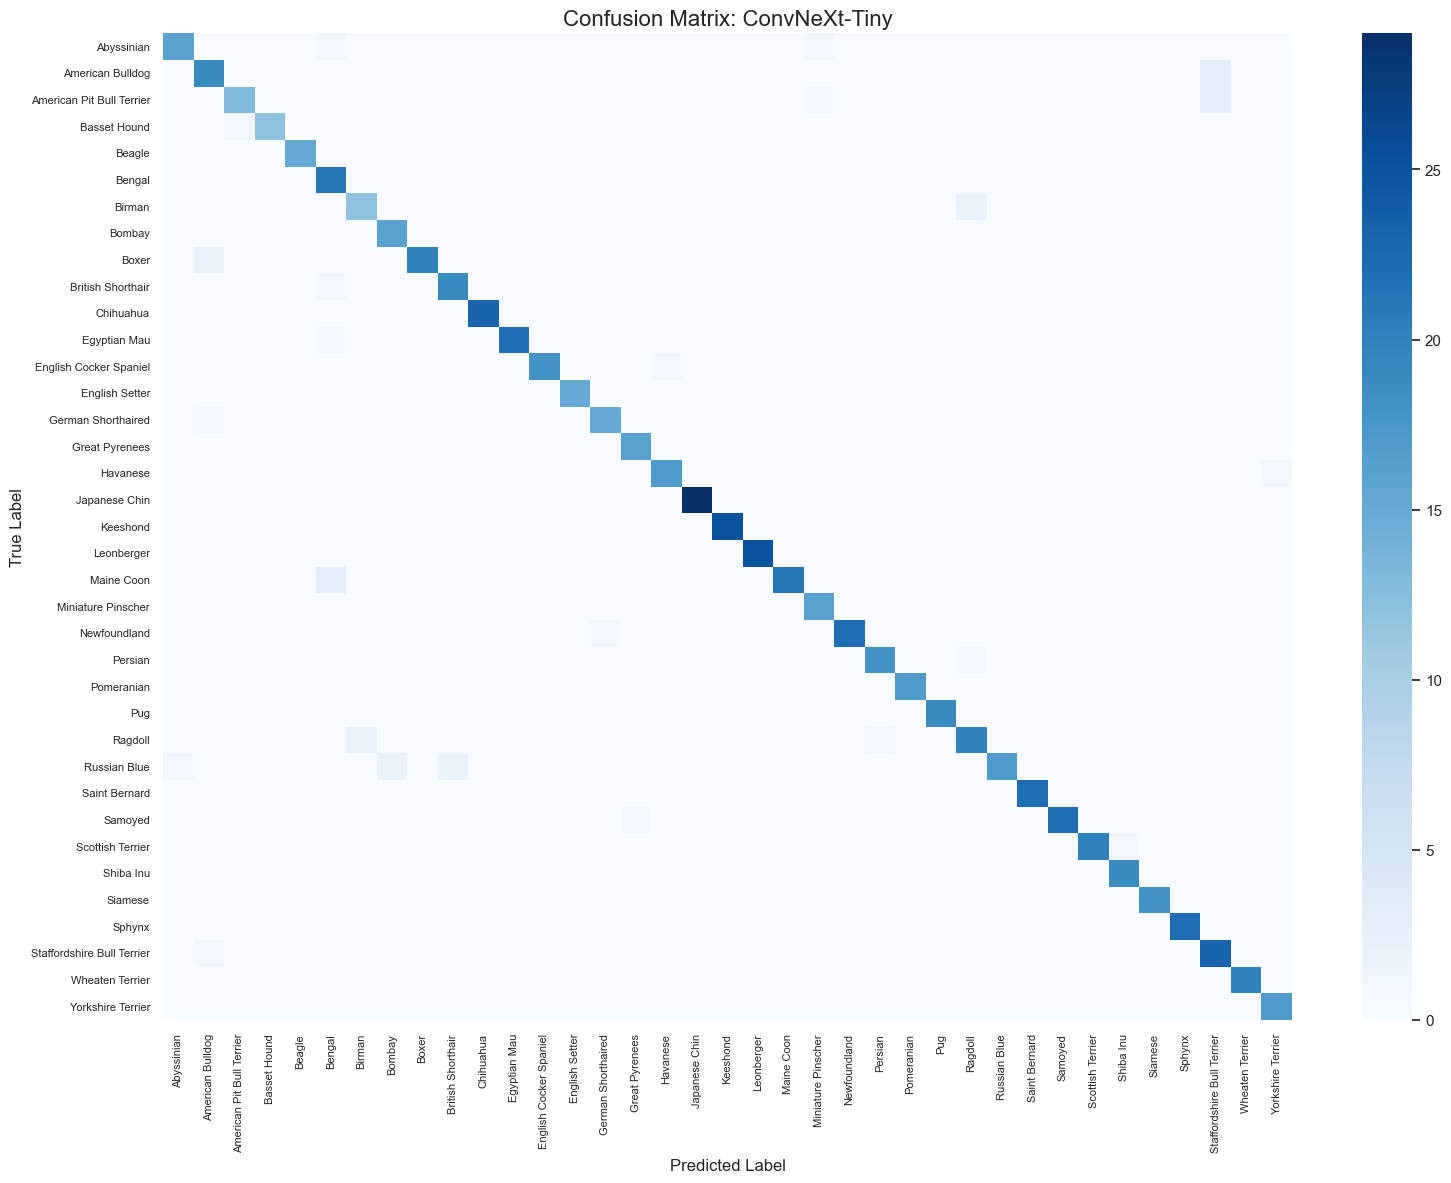


--- Top 5 Most Confused Class Pairs ---
True: Maine Coon                | Predicted: Bengal                    | Occurrences: 3
True: American Pit Bull Terrier | Predicted: Staffordshire Bull Terrier | Occurrences: 3
True: American Bulldog          | Predicted: Staffordshire Bull Terrier | Occurrences: 3
True: Russian Blue              | Predicted: British Shorthair         | Occurrences: 2
True: Ragdoll                   | Predicted: Birman                    | Occurrences: 2


In [19]:
best_model_name = 'ConvNeXt-Tiny'
eval_model = models_dict[best_model_name]
eval_model.eval()

all_preds = []
all_labels = []
misclassified_samples = []

print(f"Collecting predictions from {best_model_name} on the validation set...")

with torch.no_grad():
    for images, labels, _ in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = eval_model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        for i in range(len(preds)):
            if preds[i] != labels[i] and len(misclassified_samples) < 5:
                misclassified_samples.append({
                    'image': images[i].unsqueeze(0),
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item()
                })

print("\n--- Detailed Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

np.fill_diagonal(cm, 0)
top_errors_idx = np.argsort(cm, axis=None)[-5:][::-1]

print("\n--- Top 5 Most Confused Class Pairs ---")
for idx in top_errors_idx:
    true_idx = idx // num_classes
    pred_idx = idx % num_classes
    error_count = cm[true_idx, pred_idx]
    if error_count > 0:
        print(f"True: {class_names[true_idx]:<25} | Predicted: {class_names[pred_idx]:<25} | Occurrences: {error_count}")

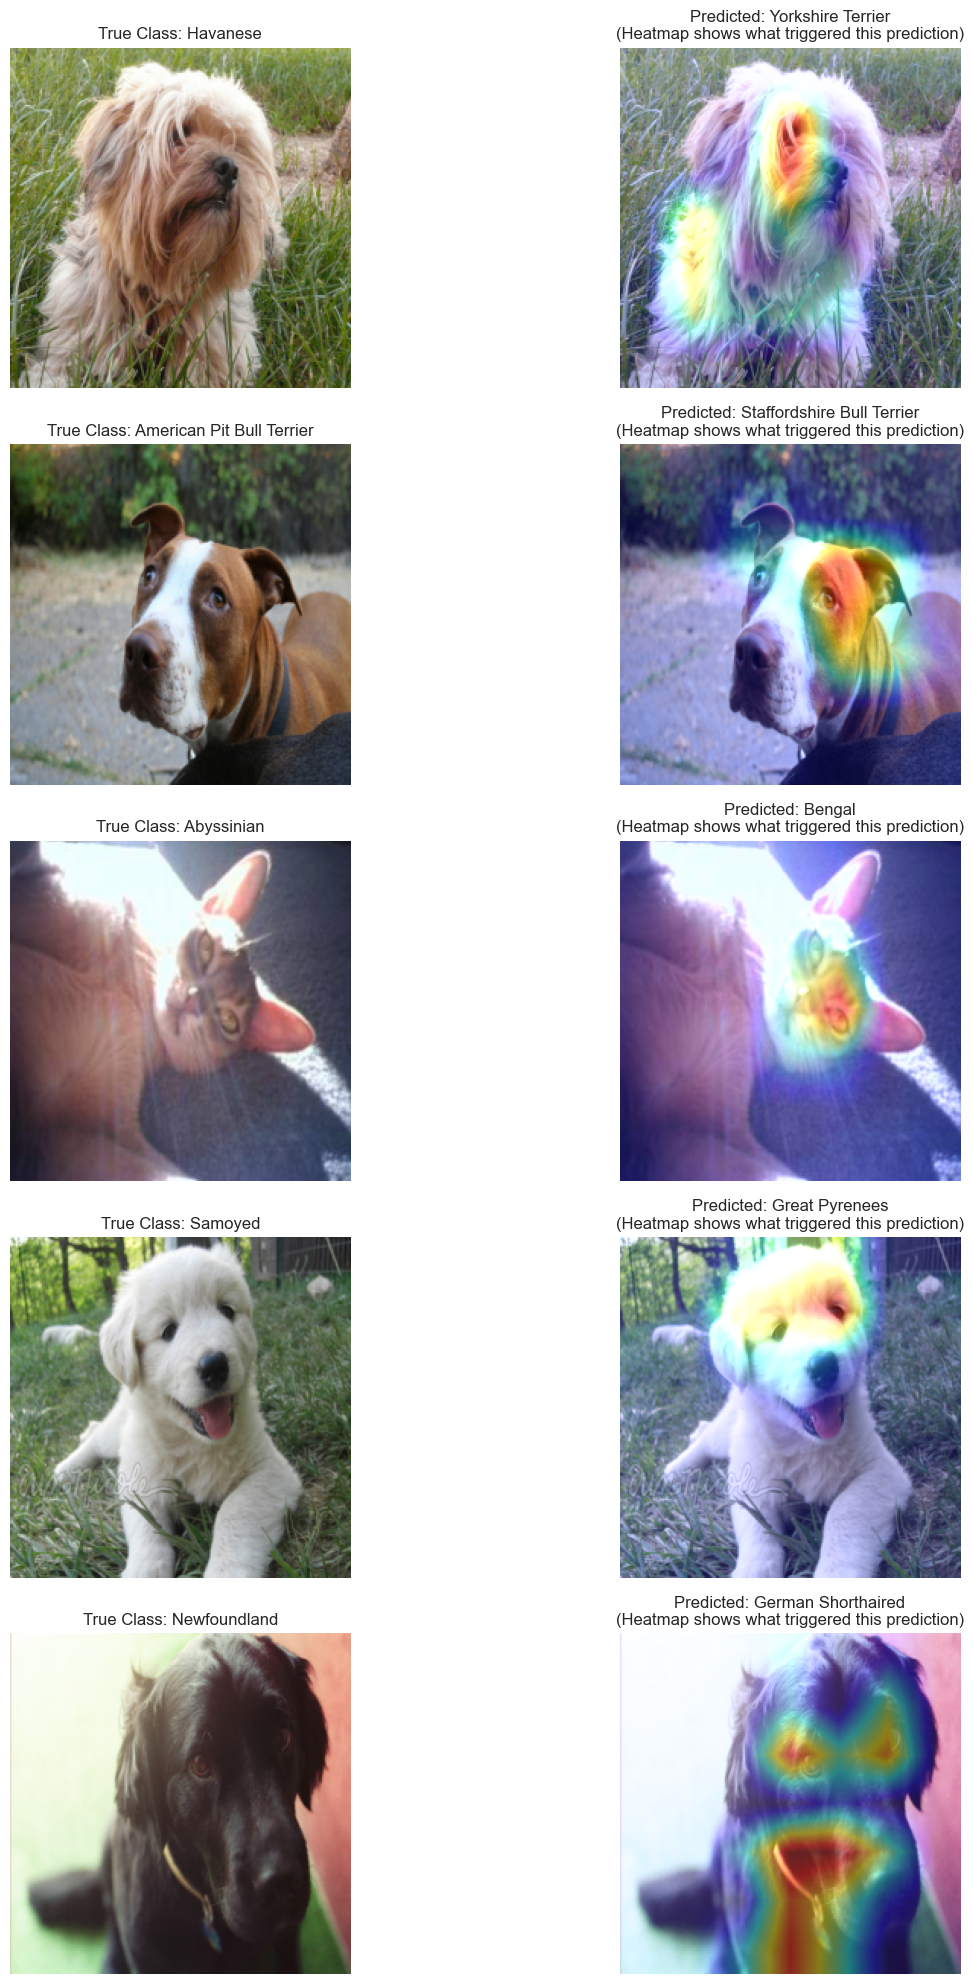

In [21]:
target_layer = models_dict['ConvNeXt-Tiny'].features[-1]
cam_generator = MinimalGradCAM(eval_model, target_layer)

plt.figure(figsize=(15, 4 * len(misclassified_samples)))

for i, sample in enumerate(misclassified_samples):
    img_tensor = sample['image']
    true_label_idx = sample['true_label']
    pred_label_idx = sample['pred_label']
    
    heatmap_pred, _ = cam_generator(img_tensor, class_idx=pred_label_idx)
    overlay_pred = overlay_heatmap(img_tensor[0], heatmap_pred)
    
    img_display = denormalize(img_tensor[0].cpu()).permute(1, 2, 0).detach().numpy()
    
    plt.subplot(len(misclassified_samples), 2, 2 * i + 1)
    plt.imshow(img_display)
    plt.title(f"True Class: {class_names[true_label_idx]}", fontsize=12)
    plt.axis('off')
    
    plt.subplot(len(misclassified_samples), 2, 2 * i + 2)
    plt.imshow(overlay_pred)
    plt.title(f"Predicted: {class_names[pred_label_idx]}\n(Heatmap shows what triggered this prediction)", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()